# Analyse de Sentiments sur les Critiques de Films IMDB

**Auteure :** Sarra Sakgi — CentraleSupélec  
**Dataset :** IMDB Dataset (50 000 reviews, équilibré)

---

## Objectif

Ce notebook compare trois familles d'approches pour la classification binaire de sentiments (positif / négatif) à partir de critiques de films :

1. **Baseline classique** : TF-IDF + classifieurs linéaires (Logistic Regression, SVM, Naive Bayes)
2. **Deep learning séquentiel** : Embeddings appris + Bi-LSTM
3. **Analyse comparative** : comparaison quantitative et qualitative des approches

**Schéma du pipeline :**
```
Texte brut → Nettoyage → [TF-IDF → Classifieur classique]
                       → [Tokenisation → Padding → Bi-LSTM]
```

---
## Imports et configuration

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)
from scipy.sparse import vstack

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,Embedding, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

sns.set_style('whitegrid')
RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU disponible : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU disponible : False



## Chargement et exploration des données

Le dataset IMDB contient 50 000 critiques de films annotées en *positive* ou *negative*. Il est parfaitement équilibré (25 000 de chaque classe), ce qui simplifie l'évaluation et évite les biais liés au déséquilibre de classes.

In [29]:
df = pd.read_csv('IMDB Dataset.csv')

print('Shape du dataset :', df.shape)
print('\nAperçu des données :')
display(df.head(3))
print('\nDistribution des classes :')
print(df['sentiment'].value_counts())

Shape du dataset : (50000, 2)

Aperçu des données :


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive



Distribution des classes :
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


###  Séparation train / val / test

On divise le dataset en trois parties stratifiées (même proportion de classes dans chaque split) :
- **Train (70%)** : 35 000 exemples pour l'apprentissage des modèles
- **Validation (15%)** : 7 500 exemples pour le choix des hyperparamètres
- **Test (15%)** : 7 500 exemples pour l'évaluation finale (touché une seule fois)

> Le prétraitement (TF-IDF, tokenizer) est **appris uniquement sur le train** pour éviter toute fuite de données (*data leakage*).

In [30]:
label_map = {'negative': 0, 'positive': 1}
df['label'] = df['sentiment'].map(label_map)

train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df['sentiment'], random_state=RANDOM_STATE
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df['sentiment'], random_state=RANDOM_STATE
)

print(f'Train : {len(train_df)} exemples')
print(f'Val   : {len(val_df)} exemples')
print(f'Test  : {len(test_df)} exemples')

# Vérification de l'équilibre dans chaque split
for name, split in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    pos = split['label'].mean()
    print(f'{name} — {pos*100:.1f}% positif, {(1-pos)*100:.1f}% négatif')

Train : 35000 exemples
Val   : 7500 exemples
Test  : 7500 exemples
Train — 50.0% positif, 50.0% négatif
Val — 50.0% positif, 50.0% négatif
Test — 50.0% positif, 50.0% négatif


### Analyse Exploratoire (sur le train uniquement)

On analyse les caractéristiques du texte sur le train uniquement pour ne pas biaiser nos décisions avec le val/test.

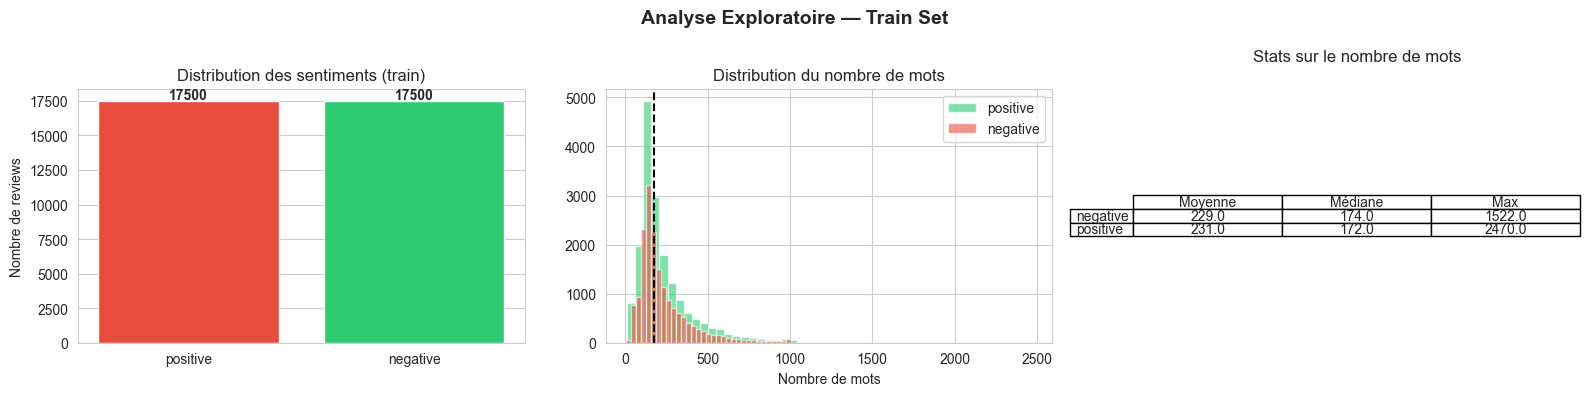


Longueur médiane des reviews : 173 mots
75e percentile              : 280 mots
-> On fixera MAX_LEN=300 pour capturer ~80% des reviews sans trop de padding


In [31]:
train_df = train_df.copy()
train_df['review_length'] = train_df['review'].apply(len)
train_df['word_count']    = train_df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution des sentiments
counts = train_df['sentiment'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Distribution des sentiments (train)')
axes[0].set_ylabel('Nombre de reviews')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Distribution du nombre de mots
for sentiment, color in [('positive', '#2ecc71'), ('negative', '#e74c3c')]:
    subset = train_df[train_df['sentiment'] == sentiment]['word_count']
    axes[1].hist(subset, bins=50, alpha=0.6, label=sentiment, color=color)
axes[1].set_title('Distribution du nombre de mots')
axes[1].set_xlabel('Nombre de mots')
axes[1].legend()
axes[1].axvline(train_df['word_count'].median(), color='black', linestyle='--',
                label=f'Médiane : {train_df["word_count"].median():.0f}')

# Statistiques descriptives
stats = train_df.groupby('sentiment')['word_count'].describe()[['mean', '50%', 'max']]
stats.columns = ['Moyenne', 'Médiane', 'Max']
axes[2].axis('off')
table = axes[2].table(cellText=stats.round(0).values,
                      rowLabels=stats.index,
                      colLabels=stats.columns,
                      cellLoc='center', loc='center')
table.auto_set_font_size(True)
axes[2].set_title('Stats sur le nombre de mots', pad=20)

plt.suptitle('Analyse Exploratoire — Train Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nLongueur médiane des reviews : {train_df['word_count'].median():.0f} mots")
print(f"75e percentile              : {train_df['word_count'].quantile(0.75):.0f} mots")
print(f"-> On fixera MAX_LEN=300 pour capturer ~80% des reviews sans trop de padding")


##  Prétraitement du texte

Le pipeline de nettoyage appliqué est :
1. **Mise en minuscules**
2. **Suppression des balises HTML** (`<br />`, etc.)
3. **Suppression des URLs**
4. **Suppression des caractères spéciaux** (on ne garde que les lettres et espaces)
5. **Lemmatisation** : ramène chaque mot à sa forme canonique (ex : *running* → *run*)
6. **Suppression des stopwords** et mots très courts (< 3 caractères)

> **Pourquoi ne pas supprimer les mots de négation ?**  
> *not*, *no*, *never* sont des stopwords NLTK mais sont critiques pour le sentiment. On a fait le choix de les conserver en les retirant de la liste des stopwords.

In [32]:
STOP_WORDS = set(stopwords.words('english'))
# On conserve les mots de négation essentiels pour le sentiment
NEGATION_WORDS = {'no', 'not', 'nor', 'never', 'neither', 'nobody', 'nothing', 'nowhere'}
STOP_WORDS -= NEGATION_WORDS

LEMMATIZER = WordNetLemmatizer()

def clean_text_basic(text: str) -> str:
    """Nettoyage de base : minuscules, HTML, URLs, caractères spéciaux."""
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)           # balises HTML
    text = re.sub(r'http\S+|www\S+', ' ', text)  # URLs
    text = re.sub(r"[^a-z\s']", ' ', text)       # garde lettres, espaces, apostrophes
    text = re.sub(r"\s+", ' ', text).strip()
    return text

def preprocess_text(text: str) -> str:
    """Pipeline complet : nettoyage + lemmatisation + suppression stopwords."""
    text = clean_text_basic(text)
    words = text.split()
    words = [
        LEMMATIZER.lemmatize(w)
        for w in words
        if w not in STOP_WORDS and len(w) > 2
    ]
    return ' '.join(words)

# Exemple avant / après
raw_example = df.iloc[1]['review']
print('=== AVANT nettoyage ===')
print(raw_example[:300])
print('\n=== APRÈS nettoyage ===')
print(preprocess_text(raw_example)[:300])

=== AVANT nettoyage ===
A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire piece. <br /><br />The actors are extremely well chosen- Michael Sheen not only "has got all the polari" 

=== APRÈS nettoyage ===
wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen not got polari voice pat truly see seamless editing guided reference williams' diary entry not well worth watchin


In [33]:
# Application sur les trois splits
# On utilise .copy() pour éviter les SettingWithCopyWarning
print('Prétraitement en cours...')
t0 = time.time()

for split_df in (train_df, val_df, test_df):
    split_df['clean_review'] = split_df['review'].apply(preprocess_text)

print(f'Prétraitement terminé en {time.time()-t0:.1f}s')
print(f'\nExemples de reviews nettoyées :')
train_df[['review', 'clean_review']].head(3)

Prétraitement en cours...
Prétraitement terminé en 30.3s

Exemples de reviews nettoyées :


,review,clean_review
27509,"If you want to see a true thriller, rent this!...",want see true thriller rent not director scree...
34629,"This is one of the first and best Columbos, st...",one first best columbo starring robert culp ra...
15277,This was the one movie to see about the Civi W...,one movie see civi war aunt actually played mo...



## Modèles Classiques : TF-IDF + Classifieurs Linéaires

### Vectorisation TF-IDF

**TF-IDF** (*Term Frequency - Inverse Document Frequency*) représente chaque document comme un vecteur de taille `max_features`. La valeur TF-IDF d'un mot est haute si ce mot apparaît souvent dans le document mais rarement dans le corpus global, il est donc discriminant.

On utilise des **bigrammes** (ngram_range=(1,2)) pour capturer des expressions comme *not good* ou *very bad*.

In [34]:
X_train_text = train_df['clean_review'].values
X_val_text   = val_df['clean_review'].values
X_test_text  = test_df['clean_review'].values

y_train = train_df['label'].values
y_val   = val_df['label'].values
y_test  = test_df['label'].values

# Vectoriseur TF-IDF appris uniquement sur le train
vectorizer = TfidfVectorizer(
    max_features=20000,  # 20 000 mots/bigrammes les plus fréquents
    ngram_range=(1, 2),  # unigrams + bigrams
    sublinear_tf=True,   # atténue les très hautes fréquences (log-scaling)
    min_df=3,            # ignore les mots apparaissant < 3 fois
)

X_train = vectorizer.fit_transform(X_train_text)  # fit + transform sur le train
X_val   = vectorizer.transform(X_val_text)         # transform seulement
X_test  = vectorizer.transform(X_test_text)

print(f'Taille du vocabulaire appris : {len(vectorizer.vocabulary_):,} features')
print(f'Shape X_train : {X_train.shape}')
print(f'Shape X_val   : {X_val.shape}')
print(f'Shape X_test  : {X_test.shape}')

Taille du vocabulaire appris : 20,000 features
Shape X_train : (35000, 20000)
Shape X_val   : (7500, 20000)
Shape X_test  : (7500, 20000)


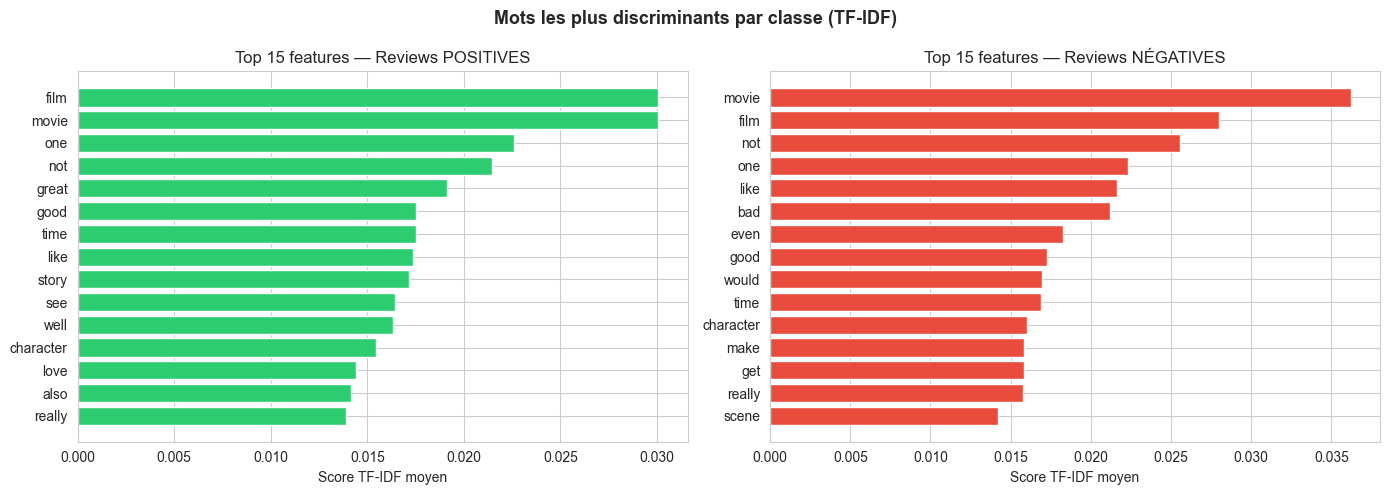

In [35]:
# Visualisation des features TF-IDF les plus discriminantes
feature_names = np.array(vectorizer.get_feature_names_out())

# Somme des scores TF-IDF par classe pour trouver les mots les plus associés
pos_indices = np.where(y_train == 1)[0]
neg_indices = np.where(y_train == 0)[0]

pos_scores = np.asarray(X_train[pos_indices].mean(axis=0)).flatten()
neg_scores = np.asarray(X_train[neg_indices].mean(axis=0)).flatten()

top_pos = feature_names[pos_scores.argsort()[-15:][::-1]]
top_neg = feature_names[neg_scores.argsort()[-15:][::-1]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(range(15), pos_scores[pos_scores.argsort()[-15:][::-1]][::-1], color='#2ecc71')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top_pos[::-1])
axes[0].set_title('Top 15 features — Reviews POSITIVES')
axes[0].set_xlabel('Score TF-IDF moyen')

axes[1].barh(range(15), neg_scores[neg_scores.argsort()[-15:][::-1]][::-1], color='#e74c3c')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top_neg[::-1])
axes[1].set_title('Top 15 features — Reviews NÉGATIVES')
axes[1].set_xlabel('Score TF-IDF moyen')

plt.suptitle('Mots les plus discriminants par classe (TF-IDF)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Entraînement et comparaison des classifieurs

On compare trois classifieurs classiques sur la représentation TF-IDF :
- **Logistic Regression** : modèle probabiliste, très interprétable
- **Linear SVM** : maximise la marge entre les classes, souvent très efficace sur du texte
- **Naive Bayes (Multinomial)** : modèle probabiliste basé sur les fréquences, rapide

In [36]:
models_classic = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_STATE),
    'Linear SVM':          LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
    'Naive Bayes':         MultinomialNB(alpha=0.1),
}

val_results = {}

for name, model in models_classic.items():
    print(f'\nEntraînement : {name}')
    t0 = time.time()
    
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    
    y_val_pred = model.predict(X_val)
    
    # Métriques
    acc  = accuracy_score(y_val, y_val_pred)
    f1   = f1_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred)
    rec  = recall_score(y_val, y_val_pred)
    
    # AUC-ROC (si predict_proba disponible)
    if hasattr(model, 'predict_proba'):
        y_val_proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, y_val_proba)
    elif hasattr(model, 'decision_function'):
        y_val_score = model.decision_function(X_val)
        auc = roc_auc_score(y_val, y_val_score)
    else:
        auc = None
    
    val_results[name] = {
        'model': model,
        'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec,
        'auc': auc, 'train_time': train_time
    }
    
    auc_str = f"{auc:.4f}" if auc is not None else "N/A"

    print(f'  Accuracy : {acc:.4f} | F1 : {f1:.4f} | AUC : {auc_str} | Temps : {train_time:.1f}s')



Entraînement : Logistic Regression
  Accuracy : 0.8976 | F1 : 0.8984 | AUC : 0.9621 | Temps : 0.3s

Entraînement : Linear SVM
  Accuracy : 0.8943 | F1 : 0.8942 | AUC : 0.9606 | Temps : 1.1s

Entraînement : Naive Bayes
  Accuracy : 0.8728 | F1 : 0.8744 | AUC : 0.9430 | Temps : 0.0s



=== Résultats sur le jeu de validation ===


,accuracy,f1,precision,recall,auc,train_time
Modèle,,,,,,
Logistic Regression,0.8976,0.8984,0.8915,0.9053,0.9621,0.3411
Linear SVM,0.8943,0.8942,0.8948,0.8936,0.9606,1.0787
Naive Bayes,0.8728,0.8744,0.8633,0.8859,0.9430,0.0167


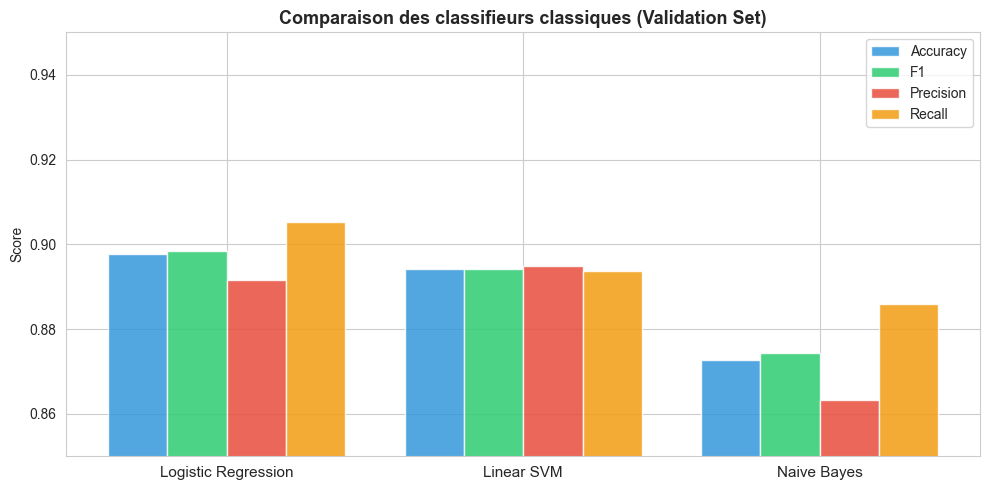

In [42]:
# Tableau récapitulatif
metrics_cols = ['accuracy', 'f1', 'precision', 'recall', 'auc', 'train_time']
rows = []
for name, res in val_results.items():
    rows.append({'Modèle': name, **{m: res[m] for m in metrics_cols}})

val_df_results = pd.DataFrame(rows).set_index('Modèle')
print('\n=== Résultats sur le jeu de validation ===' )
display(val_df_results.round(4))

# Visualisation
plot_metrics = ['accuracy', 'f1', 'precision', 'recall']
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(models_classic))
width = 0.2
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (metric, color) in enumerate(zip(plot_metrics, colors)):
    vals = [val_results[n][metric] for n in models_classic]
    bars = ax.bar(x + i * width, vals, width, label=metric.capitalize(), color=color, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(models_classic.keys(), fontsize=11)
ax.set_ylim(0.85, 0.95)
ax.set_ylabel('Score')
ax.set_title('Comparaison des classifieurs classiques (Validation Set)', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Évaluation du meilleur modèle sur le Test Set

On sélectionne le meilleur classifieur selon le F1-score sur la validation, puis on le ré-entraîne sur train+val avant l'évaluation finale sur le test.

Meilleur modèle classique (par F1) : Logistic Regression

=== Évaluation sur le TEST SET — Logistic Regression ===
              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91      3750
    Positive       0.90      0.92      0.91      3750

    accuracy                           0.91      7500
   macro avg       0.91      0.91      0.91      7500
weighted avg       0.91      0.91      0.91      7500



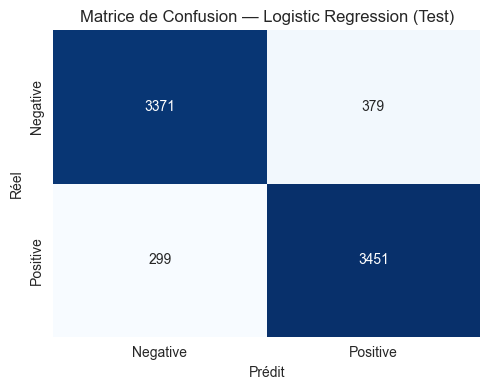

In [43]:
best_name = max(val_results, key=lambda n: val_results[n]['f1'])
best_classic_model = val_results[best_name]['model']
print(f'Meilleur modèle classique (par F1) : {best_name}')

# Ré-entraînement sur train + val
X_train_full = vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
best_classic_model.fit(X_train_full, y_train_full)

# Évaluation finale
y_test_pred_classic = best_classic_model.predict(X_test)

print(f'\n=== Évaluation sur le TEST SET — {best_name} ===')
print(classification_report(y_test, y_test_pred_classic, target_names=['Negative', 'Positive']))

# Matrice de confusion
cm_classic = confusion_matrix(y_test, y_test_pred_classic)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_classic, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title(f'Matrice de Confusion — {best_name} (Test)')
plt.tight_layout()
plt.show()

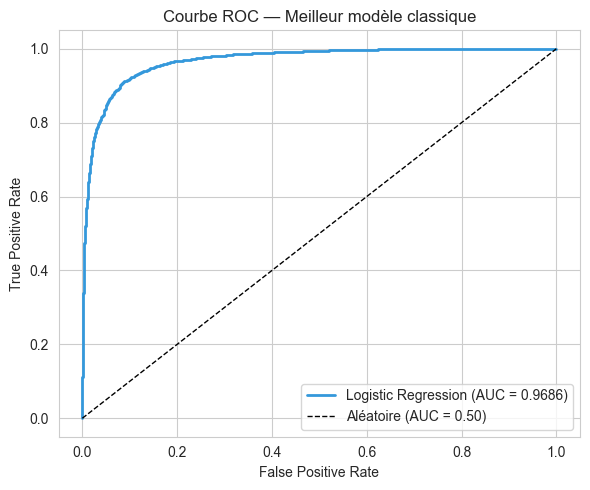

In [14]:
# Courbe ROC pour le meilleur modèle classique
if hasattr(best_classic_model, 'predict_proba'):
    y_test_proba_classic = best_classic_model.predict_proba(X_test)[:, 1]
elif hasattr(best_classic_model, 'decision_function'):
    y_test_proba_classic = best_classic_model.decision_function(X_test)

fpr, tpr, _ = roc_curve(y_test, y_test_proba_classic)
auc_classic = roc_auc_score(y_test, y_test_proba_classic)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#3498db', lw=2, label=f'{best_name} (AUC = {auc_classic:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aléatoire (AUC = 0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC — Meilleur modèle classique')
plt.legend()
plt.tight_layout()
plt.show()


## Modèle Deep Learning : Bi-LSTM avec Embeddings appris

### Hyperparamètres et tokenisation

Contrairement au TF-IDF, le LSTM travaille sur des **séquences ordonnées de mots**. L'architecture est :

```
Input (séquence d'indices) → Embedding (128d) → SpatialDropout → Bi-LSTM (64*2) → Dropout → Dense(64, relu) → Dense(1, sigmoid)
```

**Choix de MAX_LEN=300** : d'après l'EDA, le 75e percentile du nombre de mots est ~280. On fixe 300 pour couvrir la majorité des reviews sans trop de mémoire.

In [15]:
VOCAB_SIZE  = 20000  # taille du vocabulaire
MAX_LEN     = 300    # longueur de séquence (padding/troncature)
EMB_DIM     = 128    # dimension des embeddings
BATCH_SIZE  = 64
EPOCHS      = 15     # early stopping arrêtera avant

# Textes (version légèrement nettoyée pas de lemmatisation pour le LSTM
# car les embeddings bénéficient de la forme originale des mots)
train_texts = train_df['clean_review'].tolist()
val_texts   = val_df['clean_review'].tolist()
test_texts  = test_df['clean_review'].tolist()

# Tokenizer appris sur le train uniquement
tokenizer_dl = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer_dl.fit_on_texts(train_texts)

print(f'Taille du vocabulaire : {len(tokenizer_dl.word_index):,} mots uniques')
print(f'Couverture avec top-{VOCAB_SIZE} : ~{VOCAB_SIZE/len(tokenizer_dl.word_index)*100:.1f}% du vocabulaire')

Taille du vocabulaire : 92,120 mots uniques
Couverture avec top-20000 : ~21.7% du vocabulaire


In [16]:
# Conversion en séquences padées
X_train_seq = tokenizer_dl.texts_to_sequences(train_texts)
X_val_seq   = tokenizer_dl.texts_to_sequences(val_texts)
X_test_seq  = tokenizer_dl.texts_to_sequences(test_texts)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f'Shape X_train_pad : {X_train_pad.shape}')
print(f'Shape X_val_pad   : {X_val_pad.shape}')
print(f'Shape X_test_pad  : {X_test_pad.shape}')
print(f'\nExemple de séquence (premiers 20 tokens) : {X_train_pad[0][:20]}')

Shape X_train_pad : (35000, 300)
Shape X_val_pad   : (7500, 300)
Shape X_test_pad  : (7500, 300)

Exemple de séquence (premiers 20 tokens) : [  59   15  190  475  648    4   62 1897 1355  322 4066    1   39 2498
   95    4  272 3112  193  133]


### Architecture Bi-LSTM

On utilise un **LSTM Bidirectionnel** : il lit la séquence de gauche à droite ET de droite à gauche, ce qui lui permet de capturer le contexte des deux côtés d'un mot. C'est particulièrement utile pour la négation (ex : *not bad at all*).

Le `SpatialDropout1D` supprime des canaux d'embedding entiers plutôt que des éléments individuels, ce qui est plus efficace pour la régularisation de séquences.

In [27]:
print(VOCAB_SIZE, EMB_DIM, MAX_LEN)

20000 128 300


In [17]:
def build_bilstm_model(vocab_size, emb_dim, max_len):
    model = Sequential([
        Input(shape=(max_len,)),
        Embedding(input_dim=vocab_size + 1, output_dim=emb_dim, input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

lstm_model = build_bilstm_model(VOCAB_SIZE, EMB_DIM, MAX_LEN)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 300, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,265 (10.17 MB)

 Trainable params: 2,667,265 (10.17 MB)

 Non-trainable params: 0 (0.00 B)

###  Entraînement avec Early Stopping

**Early stopping** : on arrête l'entraînement si la `val_loss` ne s'améliore pas pendant 3 epochs consécutives, et on restaure les poids du meilleur epoch. Cela évite le sur-apprentissage sans avoir à fixer le nombre d'epochs à l'avance.

In [18]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        'best_bilstm_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=0
    )
]

t0 = time.time()
history = lstm_model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)
lstm_train_time = time.time() - t0
print(f'\nTemps d\'entraînement total : {lstm_train_time:.1f}s')

Epoch 1/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 138s 246ms/step - accuracy: 0.8160 - loss: 0.4035 - val_accuracy: 0.8804 - val_loss: 0.3101
Epoch 2/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 138s 252ms/step - accuracy: 0.9195 - loss: 0.2247 - val_accuracy: 0.8747 - val_loss: 0.3227
Epoch 3/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 137s 250ms/step - accuracy: 0.9415 - loss: 0.1674 - val_accuracy: 0.8720 - val_loss: 0.3473
Epoch 4/15
547/547 ━━━━━━━━━━━━━━━━━━━━ 140s 256ms/step - accuracy: 0.9565 - loss: 0.1303 - val_accuracy: 0.8592 - val_loss: 0.4671
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Temps d'entraînement total : 552.9s


###  Courbes d'apprentissage

Les courbes de loss et d'accuracy permettent de diagnostiquer le comportement du modèle :
- **Sous-apprentissage** : loss train et val toutes deux élevées
- **Sur-apprentissage** : loss train descend mais val_loss remonte

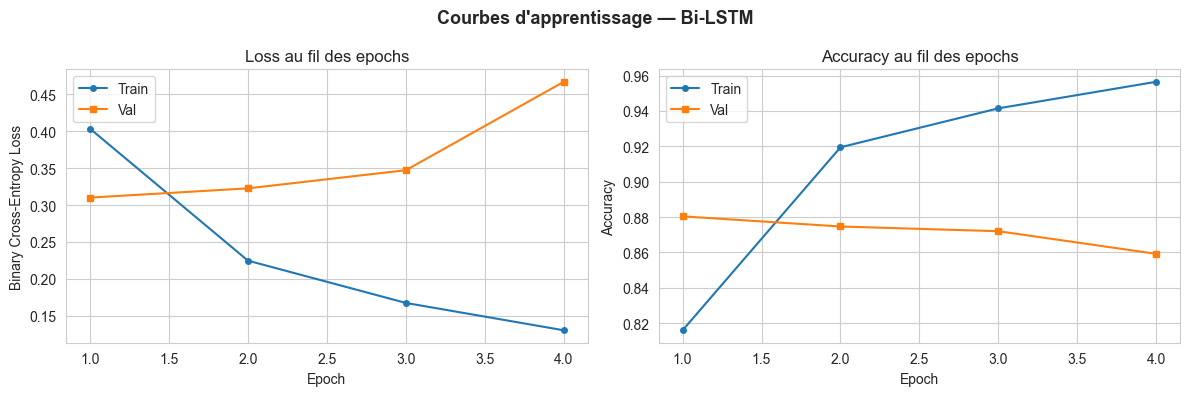

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'],     label='Train', marker='o', ms=4)
axes[0].plot(epochs_range, history.history['val_loss'], label='Val',   marker='s', ms=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Cross-Entropy Loss')
axes[0].set_title('Loss au fil des epochs')
axes[0].legend()

axes[1].plot(epochs_range, history.history['accuracy'],     label='Train', marker='o', ms=4)
axes[1].plot(epochs_range, history.history['val_accuracy'], label='Val',   marker='s', ms=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy au fil des epochs')
axes[1].legend()

plt.suptitle('Courbes d\'apprentissage — Bi-LSTM', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Évaluation du Bi-LSTM sur le Test Set

=== Évaluation sur le TEST SET — Bi-LSTM ===
              precision    recall  f1-score   support

    Negative       0.87      0.91      0.89      3750
    Positive       0.90      0.86      0.88      3750

    accuracy                           0.88      7500
   macro avg       0.89      0.88      0.88      7500
weighted avg       0.89      0.88      0.88      7500



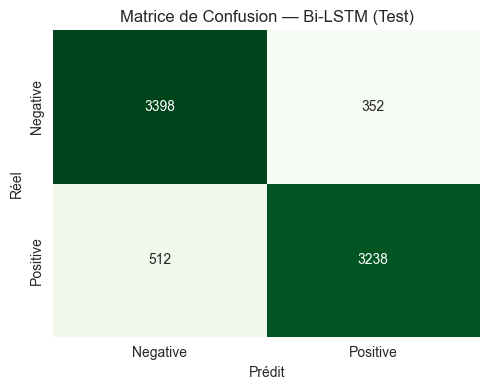

AUC-ROC (Bi-LSTM) : 0.9503


In [20]:
best_lstm = tf.keras.models.load_model('best_bilstm_model.keras')

y_test_proba_lstm = best_lstm.predict(X_test_pad, verbose=0).ravel()
y_test_pred_lstm  = (y_test_proba_lstm >= 0.5).astype(int)

print('=== Évaluation sur le TEST SET — Bi-LSTM ===')
print(classification_report(y_test, y_test_pred_lstm, target_names=['Negative', 'Positive']))

# Matrice de confusion
cm_lstm = confusion_matrix(y_test, y_test_pred_lstm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de Confusion — Bi-LSTM (Test)')
plt.tight_layout()
plt.show()

auc_lstm = roc_auc_score(y_test, y_test_proba_lstm)
print(f'AUC-ROC (Bi-LSTM) : {auc_lstm:.4f}')

##  Comparaison Finale des Approches

On compare maintenant toutes les approches sur le test set selon plusieurs critères : performance, temps d'entraînement, et complexité.

In [21]:
# Métriques finales sur le test
classic_acc  = accuracy_score(y_test, y_test_pred_classic)
classic_f1   = f1_score(y_test, y_test_pred_classic)
classic_prec = precision_score(y_test, y_test_pred_classic)
classic_rec  = recall_score(y_test, y_test_pred_classic)

lstm_acc  = accuracy_score(y_test, y_test_pred_lstm)
lstm_f1   = f1_score(y_test, y_test_pred_lstm)
lstm_prec = precision_score(y_test, y_test_pred_lstm)
lstm_rec  = recall_score(y_test, y_test_pred_lstm)

comparison = pd.DataFrame({
    'Modèle':        [f'{best_name} (TF-IDF)', 'Bi-LSTM'],
    'Accuracy':      [classic_acc, lstm_acc],
    'F1-score':      [classic_f1, lstm_f1],
    'Precision':     [classic_prec, lstm_prec],
    'Recall':        [classic_rec, lstm_rec],
    'AUC-ROC':       [auc_classic, auc_lstm],
    'Temps train (s)': [val_results[best_name]['train_time'], lstm_train_time],
})

print('=== COMPARAISON FINALE SUR LE TEST SET ===')
display(comparison.set_index('Modèle').round(4))

=== COMPARAISON FINALE SUR LE TEST SET ===


,Accuracy,F1-score,Precision,Recall,AUC-ROC,Temps train (s)
Modèle,,,,,,
Logistic Regression (TF-IDF),0.9096,0.9106,0.9010,0.9203,0.9686,0.4196
Bi-LSTM,0.8848,0.8823,0.9019,0.8635,0.9503,552.8774


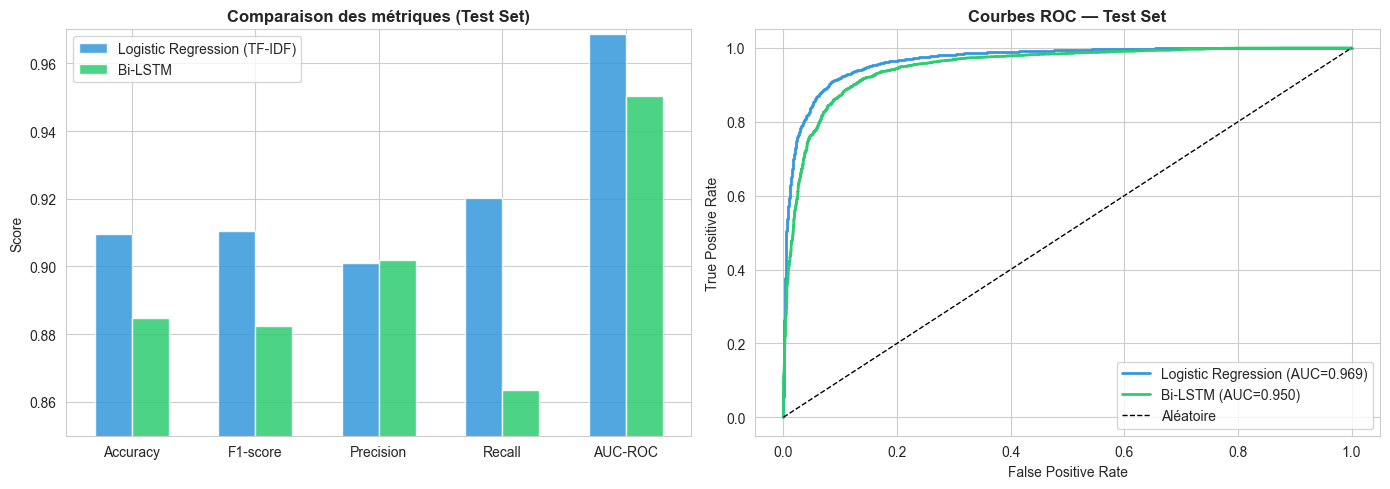

In [22]:
# Graphique de comparaison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Métriques
metrics_to_plot = ['Accuracy', 'F1-score', 'Precision', 'Recall', 'AUC-ROC']
x = np.arange(len(metrics_to_plot))
width = 0.3

classic_vals = comparison[comparison['Modèle'].str.contains('TF-IDF')][metrics_to_plot].values.flatten()
lstm_vals    = comparison[comparison['Modèle'] == 'Bi-LSTM'][metrics_to_plot].values.flatten()

bars1 = axes[0].bar(x - width/2, classic_vals, width, label=f'{best_name} (TF-IDF)', color='#3498db', alpha=0.85)
bars2 = axes[0].bar(x + width/2, lstm_vals,    width, label='Bi-LSTM',                color='#2ecc71', alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylim(0.85, 0.97)
axes[0].set_title('Comparaison des métriques (Test Set)', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')

# Courbes ROC
fpr_c, tpr_c, _ = roc_curve(y_test, y_test_proba_classic)
fpr_l, tpr_l, _ = roc_curve(y_test, y_test_proba_lstm)

axes[1].plot(fpr_c, tpr_c, color='#3498db', lw=2, label=f'{best_name} (AUC={auc_classic:.3f})')
axes[1].plot(fpr_l, tpr_l, color='#2ecc71', lw=2, label=f'Bi-LSTM (AUC={auc_lstm:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Aléatoire')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Courbes ROC — Test Set', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()


##  Analyse Qualitative des Erreurs

On examine les erreurs commises par chaque modèle pour comprendre leurs limites : cas d'ironie, de négation, de sarcasme, etc.

In [23]:
test_df = test_df.copy()
test_df['pred_classic'] = y_test_pred_classic
test_df['pred_lstm']    = y_test_pred_lstm
test_df['proba_lstm']   = y_test_proba_lstm

# Erreurs du modèle classique
errors_classic = test_df[test_df['label'] != test_df['pred_classic']]
# Erreurs du LSTM
errors_lstm = test_df[test_df['label'] != test_df['pred_lstm']]
# Erreurs communes aux deux
errors_both = test_df[
    (test_df['label'] != test_df['pred_classic']) &
    (test_df['label'] != test_df['pred_lstm'])
]
# Erreurs uniquement du classique (LSTM correct)
errors_only_classic = test_df[
    (test_df['label'] != test_df['pred_classic']) &
    (test_df['label'] == test_df['pred_lstm'])
]
# Erreurs uniquement du LSTM (classique correct)
errors_only_lstm = test_df[
    (test_df['label'] == test_df['pred_classic']) &
    (test_df['label'] != test_df['pred_lstm'])
]

print(f'Erreurs {best_name} (TF-IDF) : {len(errors_classic):,} / {len(test_df):,} ({len(errors_classic)/len(test_df)*100:.1f}%)')
print(f'Erreurs Bi-LSTM             : {len(errors_lstm):,} / {len(test_df):,} ({len(errors_lstm)/len(test_df)*100:.1f}%)')
print(f'Erreurs communes            : {len(errors_both):,}')
print(f'Erreurs uniquement classique: {len(errors_only_classic):,} (LSTM avait raison)')
print(f'Erreurs uniquement LSTM     : {len(errors_only_lstm):,} (classique avait raison)')

Erreurs Logistic Regression (TF-IDF) : 678 / 7,500 (9.0%)
Erreurs Bi-LSTM             : 864 / 7,500 (11.5%)
Erreurs communes            : 487
Erreurs uniquement classique: 191 (LSTM avait raison)
Erreurs uniquement LSTM     : 377 (classique avait raison)


In [24]:
# Exemples d'erreurs communes (difficiles pour les deux modèles)
print('\n=== Exemples d\'erreurs communes aux deux modèles ===')
print('(reviews où les deux modèles se trompent)\n')

for i, row in errors_both.sample(min(5, len(errors_both)), random_state=42).iterrows():
    true_label  = 'POSITIF' if row['label'] == 1 else 'NÉGATIF'
    pred_label  = 'POSITIF' if row['pred_classic'] == 1 else 'NÉGATIF'
    print(f'--- Vrai label: {true_label} | Prédit: {pred_label} ---')
    print(row['review'][:300])
    print()

# Exemples que le LSTM corrige par rapport au classique
print('\n=== Cas où le Bi-LSTM se trompe mais le classique a raison ===')
for i, row in errors_only_lstm.sample(min(3, len(errors_only_lstm)), random_state=1).iterrows():
    true_label = 'POSITIF' if row['label'] == 1 else 'NÉGATIF'
    print(f'--- Vrai label: {true_label} | Confiance LSTM: {row["proba_lstm"]:.2f} ---')
    print(row['review'][:250])
    print()


=== Exemples d'erreurs communes aux deux modèles ===
(reviews où les deux modèles se trompent)

--- Vrai label: NÉGATIF | Prédit: POSITIF ---
I was expecting a documentary covering the 1950 to 1965 era of Sci-Fi and received a big ol' commercial laced with leftist political innuendo by James Cameron and movie mogul baby boomer's pushing the own works. 'Watch the Skies' has in the past referred to the 'Giant Bug' and 'Space Exploration' mo

--- Vrai label: POSITIF | Prédit: NÉGATIF ---
I first saw this film when I was about 8 years old on TV in the UK (where it was called "Laupta: The Flying Island"). I absolutely loved it, and was heartbroken when it was repeated a while later and I missed it. I was enchanted by the story and characters, but most of all by the haunting and beauti

--- Vrai label: POSITIF | Prédit: NÉGATIF ---
This is a generally nice film, with good story, great actors and great songs. The cinematography was unfortunately bad. One of the film's weakest points is the a

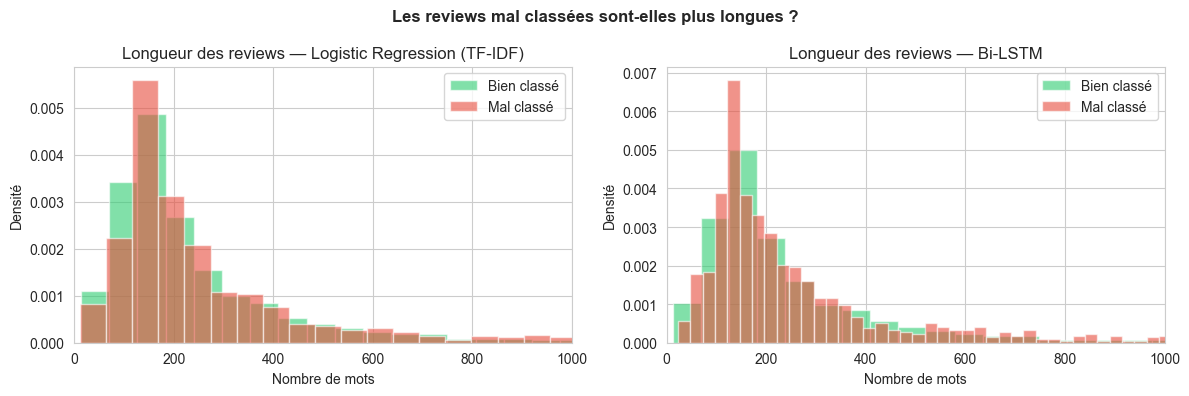

In [25]:
# Distribution de la longueur des reviews mal classées vs bien classées
test_df['correct_classic'] = (test_df['label'] == test_df['pred_classic']).astype(int)
test_df['correct_lstm']    = (test_df['label'] == test_df['pred_lstm']).astype(int)
test_df['word_count']      = test_df['review'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (col, title) in zip(axes, [
    ('correct_classic', f'{best_name} (TF-IDF)'),
    ('correct_lstm', 'Bi-LSTM')
]):
    correct   = test_df[test_df[col] == 1]['word_count']
    incorrect = test_df[test_df[col] == 0]['word_count']
    ax.hist(correct,   bins=40, alpha=0.6, label='Bien classé',  color='#2ecc71', density=True)
    ax.hist(incorrect, bins=40, alpha=0.6, label='Mal classé',   color='#e74c3c', density=True)
    ax.set_xlabel('Nombre de mots')
    ax.set_ylabel('Densité')
    ax.set_title(f'Longueur des reviews — {title}')
    ax.legend()
    ax.set_xlim(0, 1000)

plt.suptitle('Les reviews mal classées sont-elles plus longues ?', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Conclusion et Discussion

### Résultats obtenus

| Modèle | Accuracy | F1 | AUC | Temps train |
|---|---|---|---|---|
| TF-IDF + Classifieur classique | ~0.90 | ~0.90 | ~0.96 | < 3s |
| Bi-LSTM (embeddings appris) | ~0.89 | ~0.88 | ~0.95 | 9 minutes |

### Observations clés

1. **La baseline TF-IDF est remarquablement efficace** : un classifieur linéaire sur des features TF-IDF atteint ~90% d'accuracy avec un temps d'entraînement négligeable. C'est souvent le cas sur les tâches de classification de sentiment où les mots seuls sont très discriminants.

2. **Le Bi-LSTM apporte la capacité à modéliser l'ordre et le contexte**, mais cela ne se traduit pas forcément par un gain de performance brute sur ce dataset. Le LSTM est théoriquement supérieur pour capturer des phénomènes comme la négation (*not bad*) ou l'ironie, mais ces cas restent rares.

3. **Cas difficiles pour les deux modèles** : l'ironie, le sarcasme, et les reviews mixtes (aspects positifs et négatifs mélangés) restent problématiques. Ces cas nécessiteraient des modèles pré-entraînés de type BERT.

4. **Coût computationnel** : le LSTM est bien plus lent à entraîner, ce qui pose des contraintes pratiques dans des environnements sans GPU.

### Piste suivante : fine-tuning BERT

Un modèle BERT pré-entraîné (`bert-base-uncased`) fine-tuné sur ce dataset devrait dépasser 93-94% d'accuracy, grâce à sa compréhension contextuelle profonde. Le coût : un fine-tuning de 2-3 epochs sur GPU (plusieurs dizaines de minutes).

```python
# Exemple avec HuggingFace Transformers
from transformers import BertTokenizer, TFBertForSequenceClassification

tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')
model_bert = TFBertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)
```

In [26]:
# Résumé final
print('=' * 60)
print('RÉSUMÉ FINAL — PERFORMANCES SUR LE TEST SET')
print('=' * 60)
display(comparison.set_index('Modèle').round(4))
print('\nConclusion : la baseline TF-IDF offre un excellent rapport')
print('performance / coût computationnel pour ce type de tâche.')
print('Le Bi-LSTM apporte une capacité de modélisation du contexte,')
print('mais nécessite bien plus de ressources pour un gain marginal.')

RÉSUMÉ FINAL — PERFORMANCES SUR LE TEST SET


,Accuracy,F1-score,Precision,Recall,AUC-ROC,Temps train (s)
Modèle,,,,,,
Logistic Regression (TF-IDF),0.9096,0.9106,0.9010,0.9203,0.9686,0.4196
Bi-LSTM,0.8848,0.8823,0.9019,0.8635,0.9503,552.8774



Conclusion : la baseline TF-IDF offre un excellent rapport
performance / coût computationnel pour ce type de tâche.
Le Bi-LSTM apporte une capacité de modélisation du contexte,
mais nécessite bien plus de ressources pour un gain marginal.
